# LeXi: Gemini Vocabulary Learning Agent

`LeXi`는 `Lexicon`에서 이름을 가져온 영어 기술 문서 학습 에이전트다.
이 노트북은 과제 요구사항에 맞춰 설계 문서와 LangGraph 기반 최소 구현을 함께 담는다.

## Agent Design

- **Theme**: Education & Learning
- **Purpose**: 영어 기술 문장이나 문단에서 학습이 필요한 핵심 단어를 추출하고, 문맥 기반 뜻과 출처 문장을 구조화한다.
- **Key Features**:
  - Gemini가 학습 가치가 높은 단어 후보를 추출
  - Gemini가 각 단어를 문맥 기반으로 해석
  - LangGraph 상태에 구조화된 단어장 결과 저장

```mermaid
flowchart TD
    A["User Input: English technical sentence or paragraph"]
    B["Node 1: Extract learning-worthy words"]
    C["Node 2: Build context-based vocabulary entries"]
    D["Notebook Output: Structured vocabulary list"]

    E[("Future: Vocabulary storage")]
    F[("Future: Search words and trace sources")]
    G[("Future: Frequency analysis and study priority")]
    H[("Future: Review and quiz generation")]

    A --> B --> C --> D
    C -.-> E
    E -.-> F
    E -.-> G
    G -.-> H
```

이번 단계에서는 두 개의 LangGraph 노드만 구현한다. 저장, 검색, 통계, 퀴즈는 향후 확장 범위다.


In [12]:
from __future__ import annotations

import os
from pprint import pprint

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

load_dotenv()

if not os.getenv("GOOGLE_API_KEY"):
    raise RuntimeError("GOOGLE_API_KEY must be set in the project .env file.")

llm = init_chat_model(
    model=os.getenv("GOOGLE_GENAI_MODEL", "gemini-3-flash-preview"),
    model_provider="google_genai",
    temperature=0,
)


## Foundation Building

이번 구현은 `MessagesState` 대신 작은 `custom state`를 사용한다.
핵심은 대화 이력 관리가 아니라 `입력 텍스트 -> 후보 단어 -> 단어장 엔트리` 흐름이기 때문이다.


In [13]:
class VocabularyEntry(TypedDict):
    word: str
    lemma: str
    meaning_in_context: str
    source_sentence: str
    context_note: str


class LearningState(TypedDict):
    input_text: str
    candidate_words: list[str]
    vocabulary_entries: list[VocabularyEntry]


class CandidateWords(BaseModel):
    candidate_words: list[str] = Field(
        description="학습 가치가 높은 영어 기술 단어 또는 짧은 표현 목록. 최대 5개."
    )


class VocabularyEntryModel(BaseModel):
    word: str = Field(description="원문에서의 단어 또는 표현")
    lemma: str = Field(description="정규화된 표제어")
    meaning_in_context: str = Field(description="현재 문맥에서의 한국어 뜻")
    source_sentence: str = Field(description="해당 단어가 나온 원문 문장")
    context_note: str = Field(description="왜 이런 뜻으로 읽어야 하는지에 대한 짧은 한국어 설명")


class VocabularyEntries(BaseModel):
    vocabulary_entries: list[VocabularyEntryModel]


candidate_llm = llm.with_structured_output(CandidateWords)
entry_llm = llm.with_structured_output(VocabularyEntries)


In [14]:
def extract_candidates(state: LearningState) -> dict:
    text = state["input_text"].strip()
    if not text:
        return {"candidate_words": [], "vocabulary_entries": []}

    prompt = f"""
You are helping a Korean developer study English technical writing.
Read the text and choose up to 5 English words or short terms that are worth learning.
Pick words that are important for understanding the technical meaning.
Return only the structured output.

Text:
{text}
""".strip()

    result = candidate_llm.invoke(prompt)
    candidate_words = list(dict.fromkeys(result.candidate_words))[:5]
    return {"candidate_words": candidate_words, "vocabulary_entries": []}


In [15]:
def build_vocabulary_entries(state: LearningState) -> dict:
    text = state["input_text"].strip()
    candidate_words = state["candidate_words"]
    if not text or not candidate_words:
        return {"vocabulary_entries": []}

    prompt = f"""
You are building a vocabulary list for a Korean learner reading English technical documents.
Use the text and candidate words below.
For each candidate word, return:
- word as it appears in the text
- lemma
- Korean meaning in this context
- source sentence from the text
- one short Korean context note
Return only the structured output.

Text:
{text}

Candidate words:
{", ".join(candidate_words)}
""".strip()

    result = entry_llm.invoke(prompt)
    vocabulary_entries = [entry.model_dump() for entry in result.vocabulary_entries]
    return {"vocabulary_entries": vocabulary_entries}


각 노드는 역할을 하나씩만 가진다.

- `extract_candidates`: 후보 단어 추출
- `build_vocabulary_entries`: 단어장 엔트리 생성


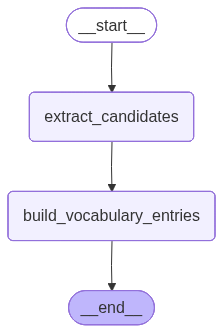

In [16]:
graph_builder = StateGraph(LearningState)
graph_builder.add_node("extract_candidates", extract_candidates)
graph_builder.add_node("build_vocabulary_entries", build_vocabulary_entries)

graph_builder.add_edge(START, "extract_candidates")
graph_builder.add_edge("extract_candidates", "build_vocabulary_entries")
graph_builder.add_edge("build_vocabulary_entries", END)

lexi_graph = graph_builder.compile()
lexi_graph


In [17]:
sample_input = {
    "input_text": (
        "Caching reduces latency, but inconsistent invalidation can cause stale data. "
        "When the API serializes responses, the schema must remain stable for backward compatibility."
    ),
    "candidate_words": [],
    "vocabulary_entries": [],
}

result = lexi_graph.invoke(sample_input)
pprint(result)


{'candidate_words': ['latency',
                     'invalidation',
                     'stale data',
                     'serializes',
                     'backward compatibility'],
 'input_text': 'Caching reduces latency, but inconsistent invalidation can '
               'cause stale data. When the API serializes responses, the '
               'schema must remain stable for backward compatibility.',
 'vocabulary_entries': [{'context_note': '데이터 요청부터 응답까지 걸리는 대기 시간을 의미합니다.',
                         'lemma': 'latency',
                         'meaning_in_context': '지연 시간',
                         'source_sentence': 'Caching reduces latency, but '
                                            'inconsistent invalidation can '
                                            'cause stale data.',
                         'word': 'latency'},
                        {'context_note': '캐시된 데이터가 더 이상 유효하지 않음을 선언하고 제거하는 과정을 '
                                         '뜻합니다.',
                  